In [1]:
import os
import glob
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
# ===========================================================================
# RESOLUTION SETTINGS
# ===========================================================================
FIG_DPI = 300          # resolution for on-screen rendering
SAVE_DPI = 600         # resolution used if figures are saved to file
FIG_SIZE = (10, 6)     # a bit larger so higher DPI detail is visible

plt.rcParams["figure.dpi"] = FIG_DPI
plt.rcParams["savefig.dpi"] = SAVE_DPI


# ===========================================================================
# CASE-INSENSITIVE LOOKUP HELPERS
# ===========================================================================
def find_sheet(file_path, wanted):
    """Return the real sheet name matching `wanted` case-insensitively."""
    xls = pd.ExcelFile(file_path)
    for name in xls.sheet_names:
        if str(name).strip().lower() == wanted.strip().lower():
            return name
    raise ValueError(f"Sheet '{wanted}' not found in {file_path}. Have: {xls.sheet_names}")


def read_sheet(file_path, wanted):
    """Read a sheet case-insensitively and lowercase all column names."""
    sheet_name = find_sheet(file_path, wanted)
    df = pd.read_excel(file_path, sheet_name=sheet_name)
    df.columns = [str(c).strip().lower() for c in df.columns]
    return df


def col(df, name):
    """Case-insensitive column accessor. Raises a clear error if missing."""
    key = name.strip().lower()
    if key in df.columns:
        return df[key]
    raise KeyError(
        f"Column '{name}' not found. Available: {list(df.columns)}"
    )


# ===========================================================================
# SHEET 1 - DISPLACEMENT PLOTS
# ===========================================================================
def plot_sheet1(sheet1, file_name):

    time1 = col(sheet1, "Time [sec]")

    # Plot 1
    plt.figure()
    plt.plot(time1, col(sheet1, "crank-coupler->Y,Displacement(abs) [mm]"), label="Y displacement")
    plt.plot(time1, col(sheet1, "crank-coupler->Z,Displacement(abs) [mm]"), label="Z displacement")
    plt.xlabel("Time [sec]")
    plt.ylabel("Displacement [mm]")
#    plt.title(f"{file_name} - crank-coupler Displacement vs Time")
    plt.legend(); plt.grid(True); plt.tight_layout()

    plt.figure()
    plt.plot(time1, col(sheet1, "coupler-rocker->Y,Displacement(abs) [mm]"), label="Y displacement")
    plt.plot(time1, col(sheet1, "coupler-rocker->Z,Displacement(abs) [mm]"), label="Z displacement")
    plt.xlabel("Time [sec]")
    plt.ylabel("Displacement [mm]")
   # plt.title(f"{file_name} - coupler-rocker Displacement vs Time")
    plt.legend(); plt.grid(True); plt.tight_layout()

    #Plot 3
    plt.figure()
    plt.plot(col(sheet1, "crank-coupler->Y,Displacement(abs) [mm]"),
             col(sheet1, "crank-coupler->Z,Displacement(abs) [mm]"))
    plt.xlabel("Y displacement [mm]")
    plt.ylabel("Z displacement [mm]")
    #plt.title(f"{file_name} - crank-coupler Y vs Z Displacement")
    
    plt.grid(True); plt.tight_layout()

    # Plot 4
    plt.figure()
    plt.plot(col(sheet1, "coupler-rocker->Y,Displacement(abs) [mm]"),
             col(sheet1, "coupler-rocker->Z,Displacement(abs) [mm]"))
    plt.xlabel("Y displacement [mm]")
    plt.ylabel("Z displacement [mm]")
    #plt.title(f"{file_name} - coupler-rocker Y vs Z Displacement")
    plt.grid(True); plt.tight_layout()

    plt.show()


# ===========================================================================
# SHEET 2 - VELOCITY PLOTS
# ===========================================================================
def plot_sheet2(sheet2, file_name):

    time2 = col(sheet2, "Time [sec]")

    # Plot 5
    plt.figure()
    plt.plot(time2, col(sheet2, "crank-coupler->Y,Velocity(abs) [mm/sec]"), label="Y Velocity")
    plt.plot(time2, col(sheet2, "crank-coupler->Z,Velocity(abs) [mm/sec]"), label="Z Velocity")
    plt.xlabel("Time [sec]")
    plt.ylabel("Velocity [mm/sec]")
    plt.legend(); plt.grid(True); plt.tight_layout()

    # # Plot 6
    plt.figure()
    plt.plot(time2, col(sheet2, "coupler-rocker->Y,Velocity(abs) [mm/sec]"), label="Y Velocity")
    plt.plot(time2, col(sheet2, "coupler-rocker->Z,Velocity(abs) [mm/sec]"), label="Z velocity")
    plt.xlabel("Time [sec]")
    plt.ylabel("Velocity [mm/sec]")
    #plt.title(f"{file_name} - coupler-rocker Velocity vs Time")
    plt.legend(); plt.grid(True); plt.tight_layout()

    # Plot 7
    plt.figure()
    plt.plot(time2, col(sheet2, "crank-coupler->RX,Velocity(abs) [degrees/sec]"), label="crank-coupler RX")
    plt.plot(time2, col(sheet2, "coupler-rocker->RX,Velocity(abs) [degrees/sec]"), label="coupler-rocker RX")
    plt.xlabel("Time [sec]")
    plt.ylabel("RX Velocity [degrees/sec]")
    plt.legend(); plt.grid(True);

    # Plot 8
    plt.figure()
    plt.plot(time2, col(sheet2, "crank-coupler->RZ,Velocity(rel) [degrees/sec]"), label="crank-coupler RZ")
    plt.plot(time2, col(sheet2, "coupler-rocker->RZ,Velocity(rel) [degrees/sec]"), label="coupler-rocker RZ")
    plt.xlabel("Time [sec]")
    plt.ylabel("RZ Velocity [degrees/sec]")
    plt.legend(); plt.grid(True); plt.tight_layout()

    plt.show()


# ===========================================================================
# MAIN
# ===========================================================================
excel_files_skel = glob.glob(os.path.join("Skeleton_Model", "*.xlsx"))


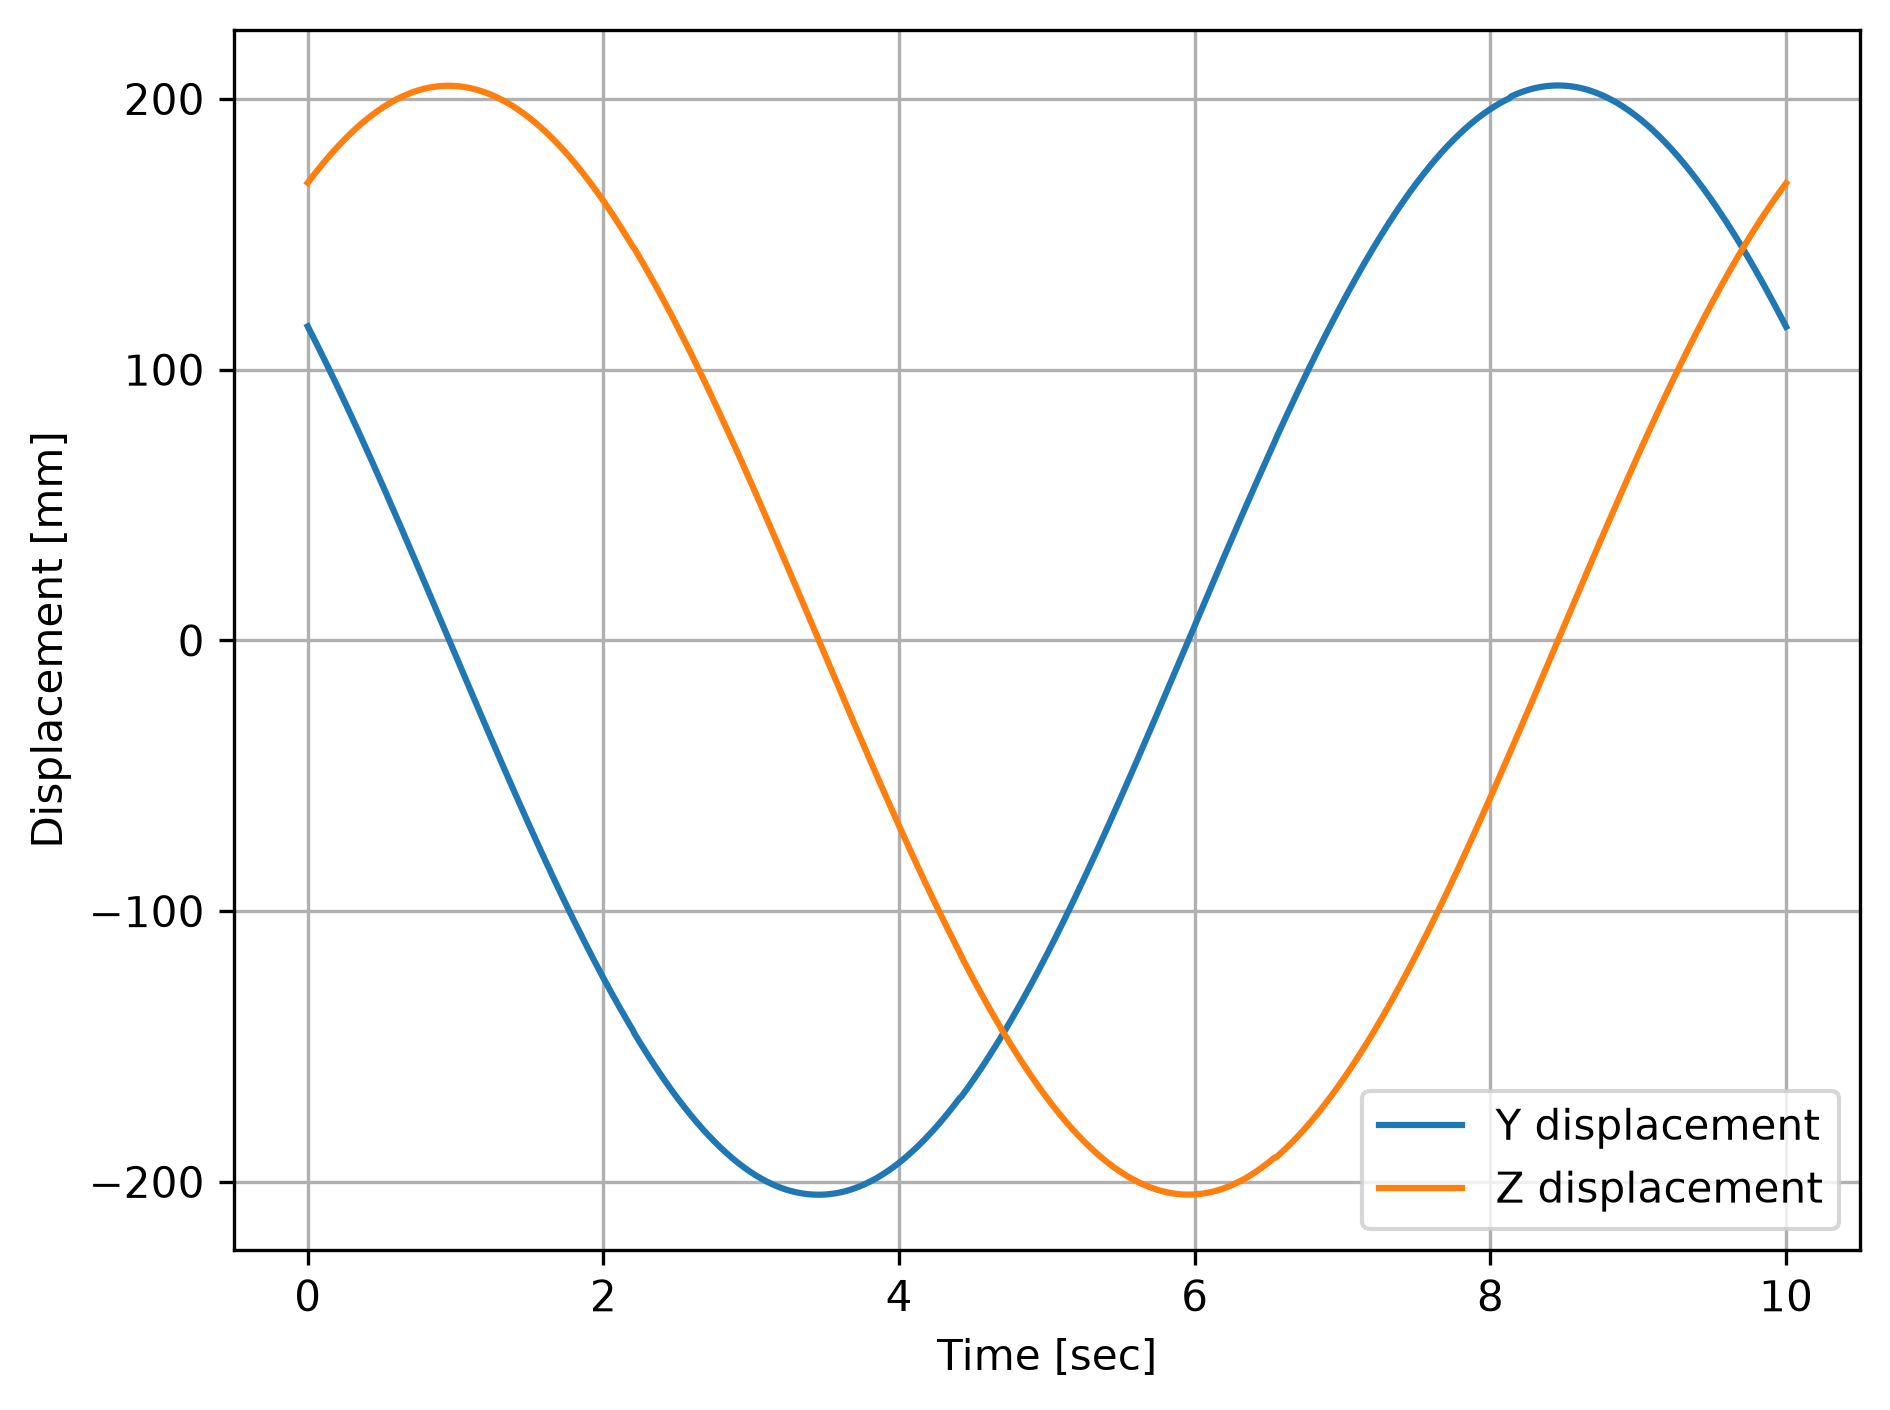

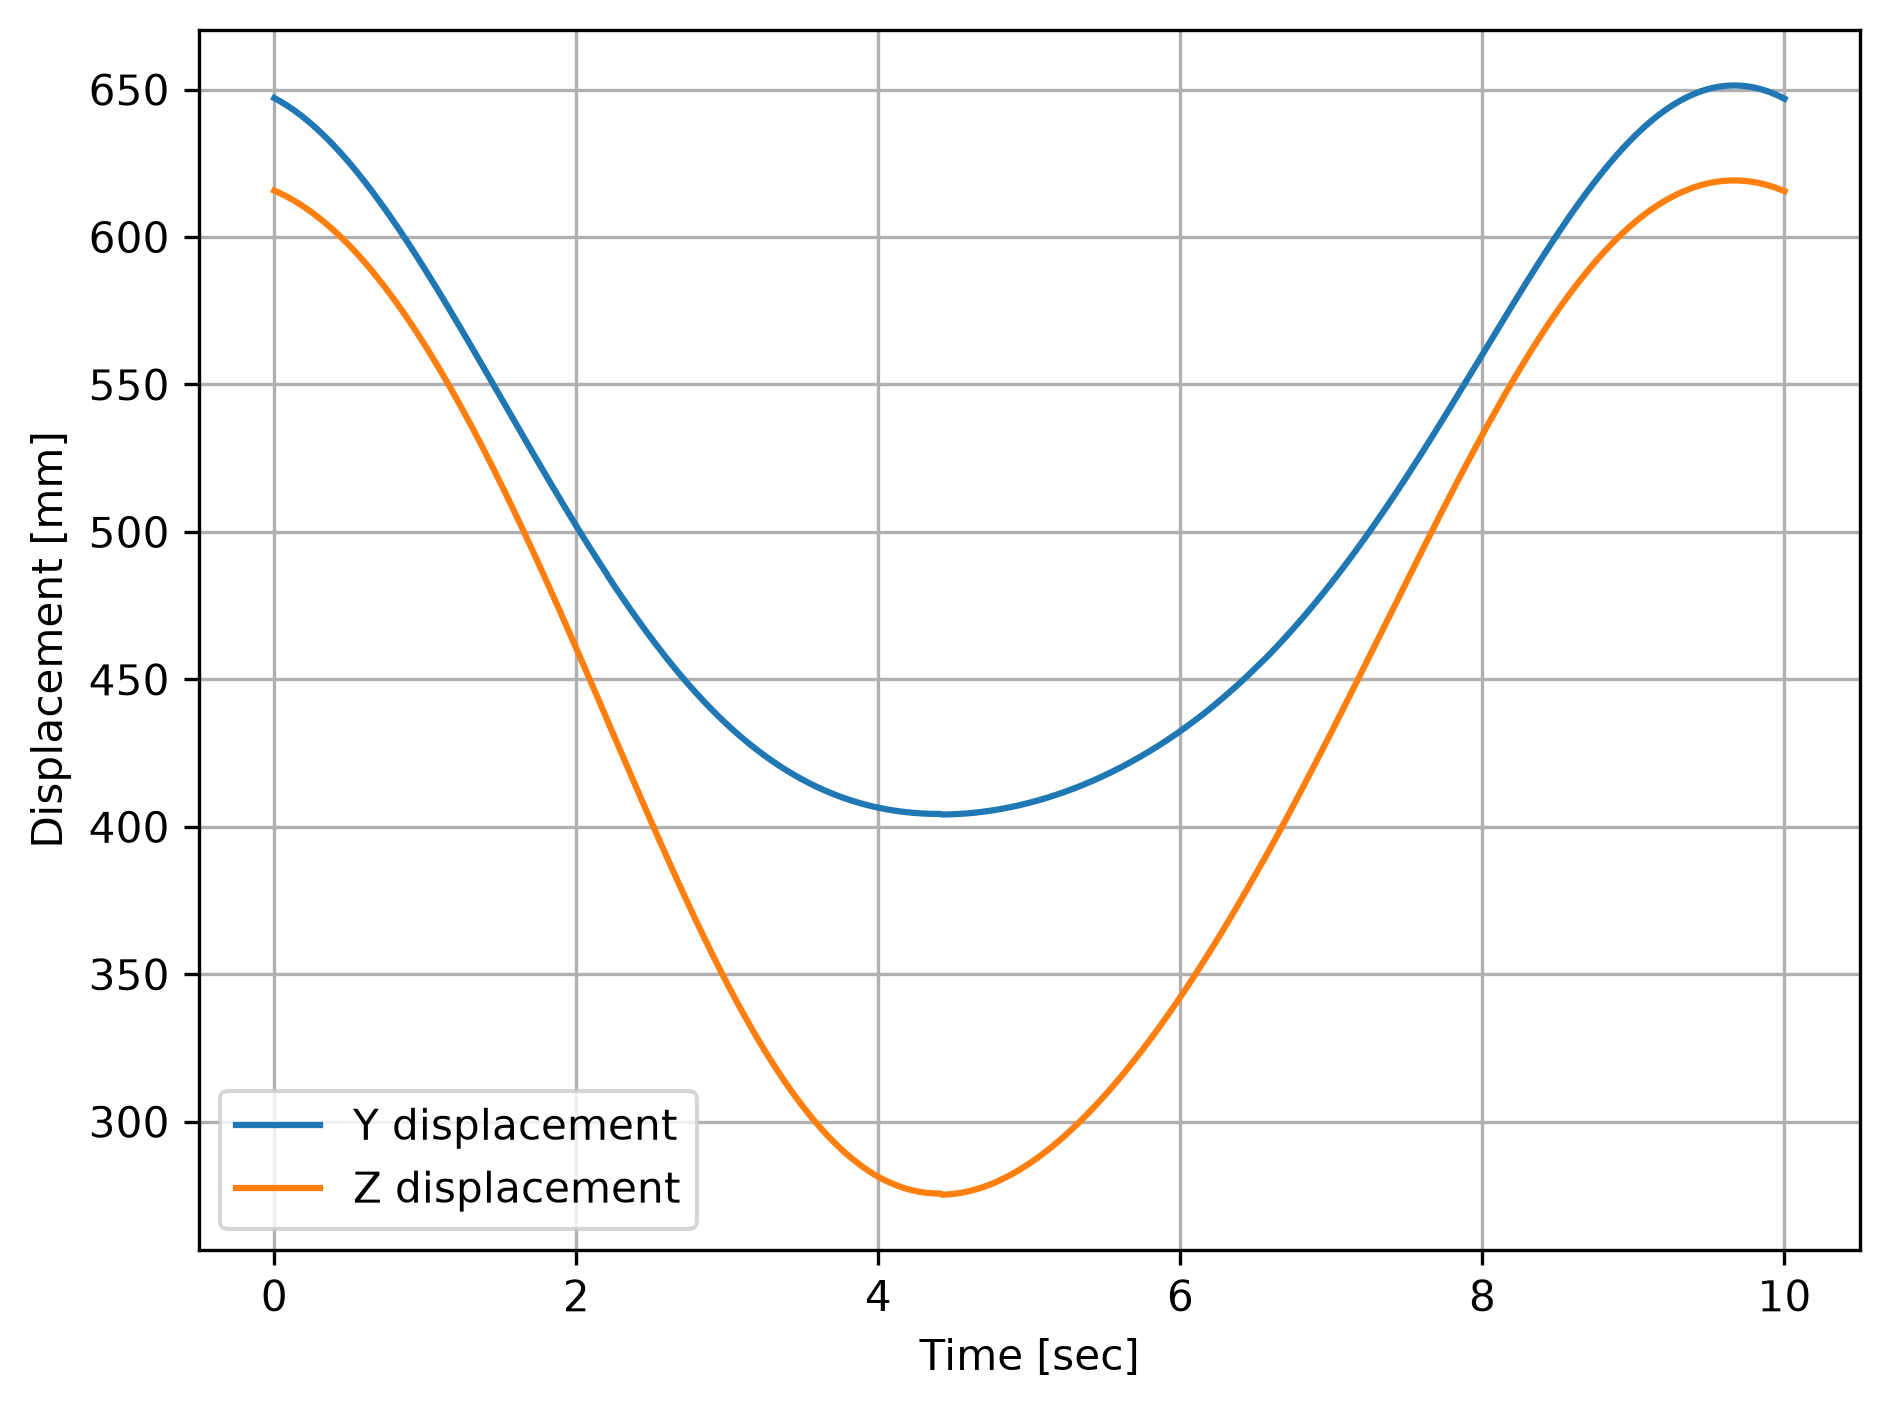

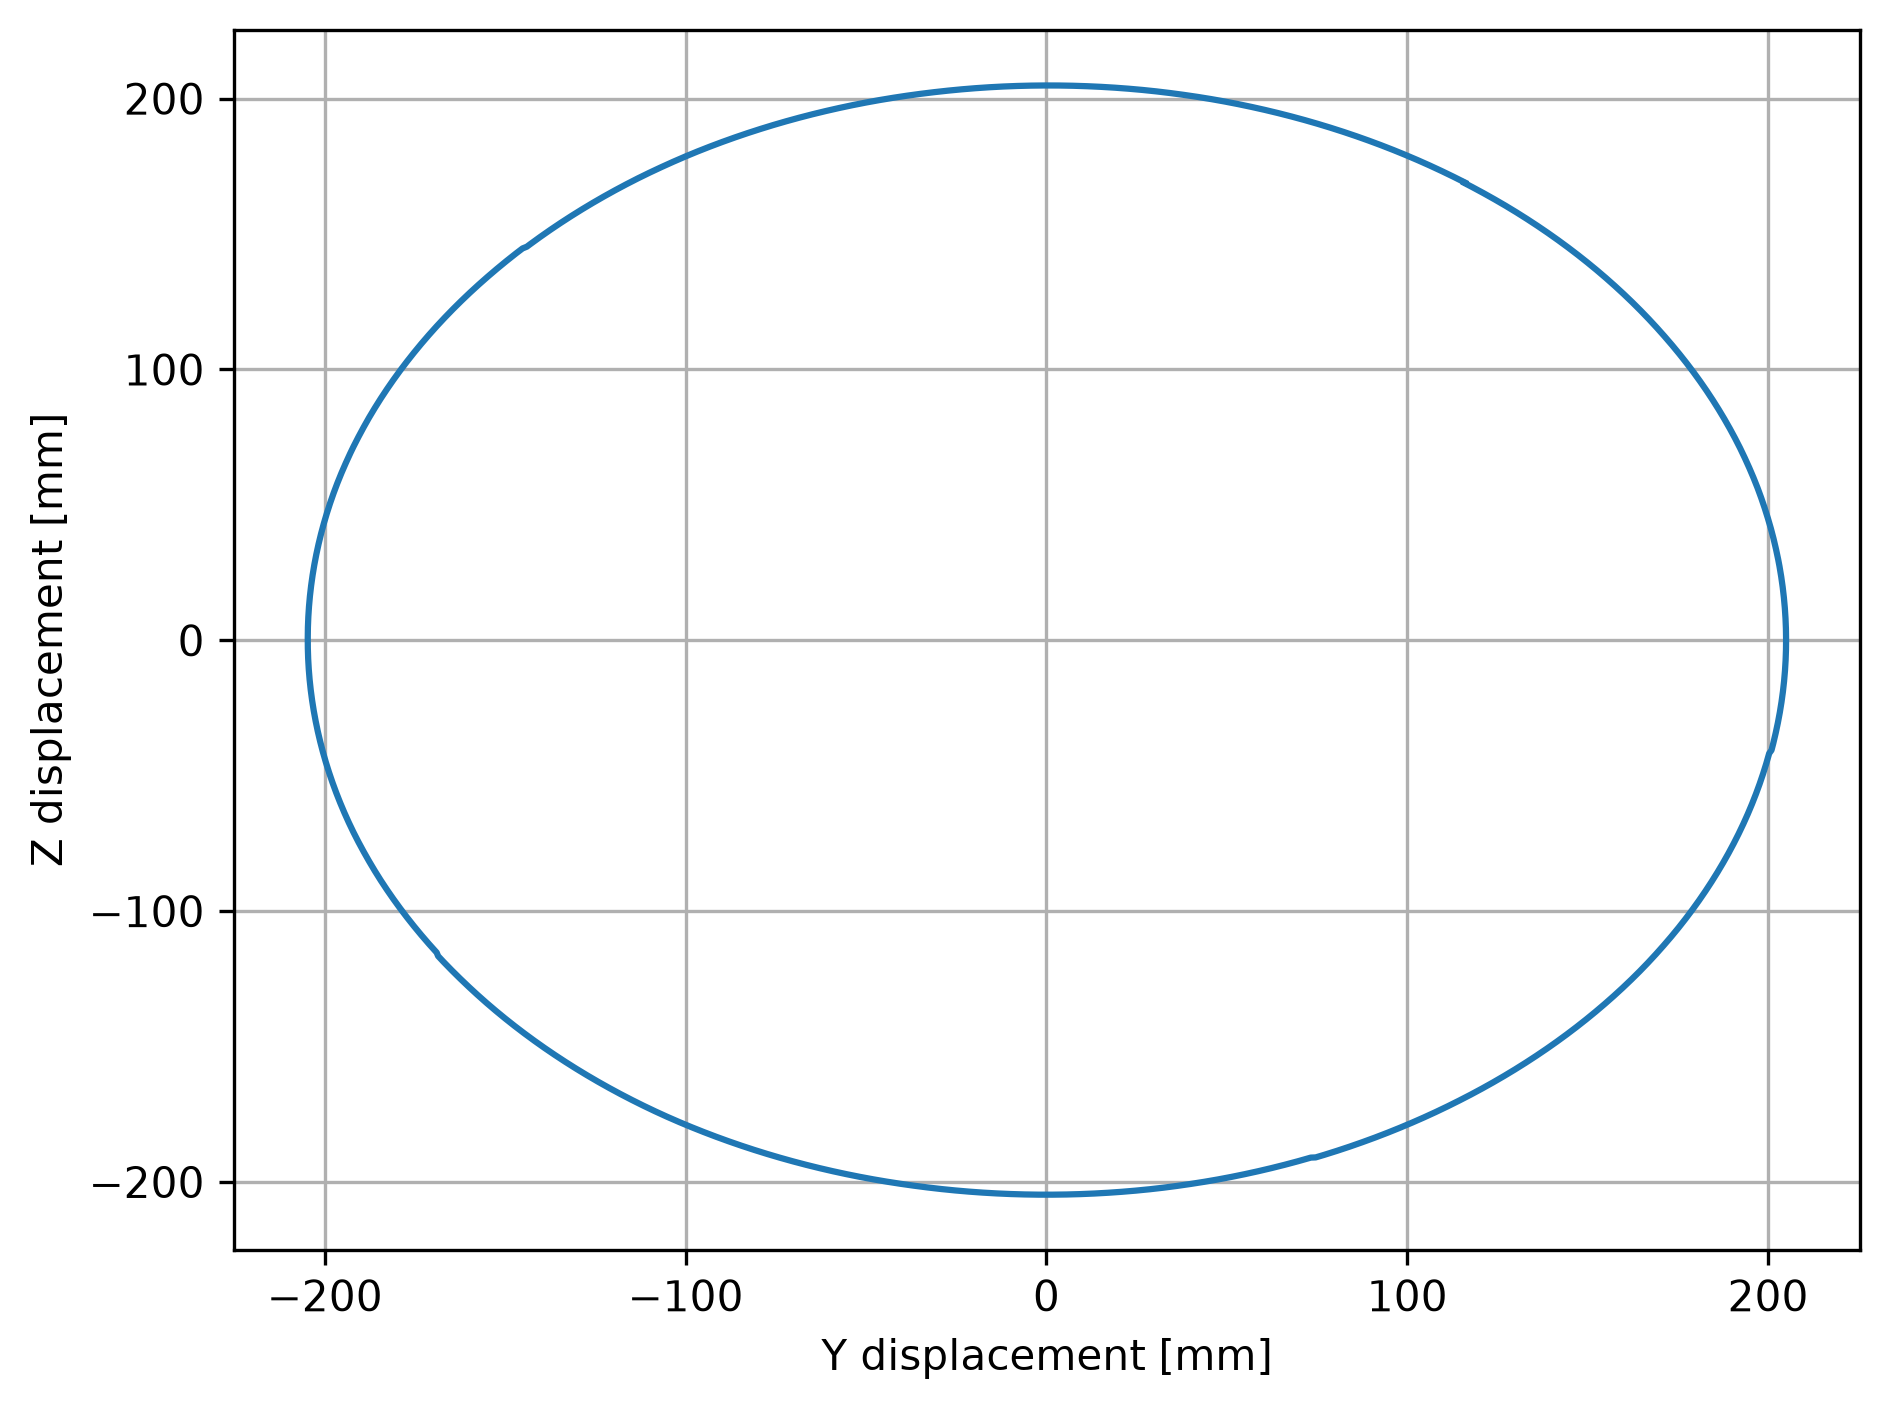

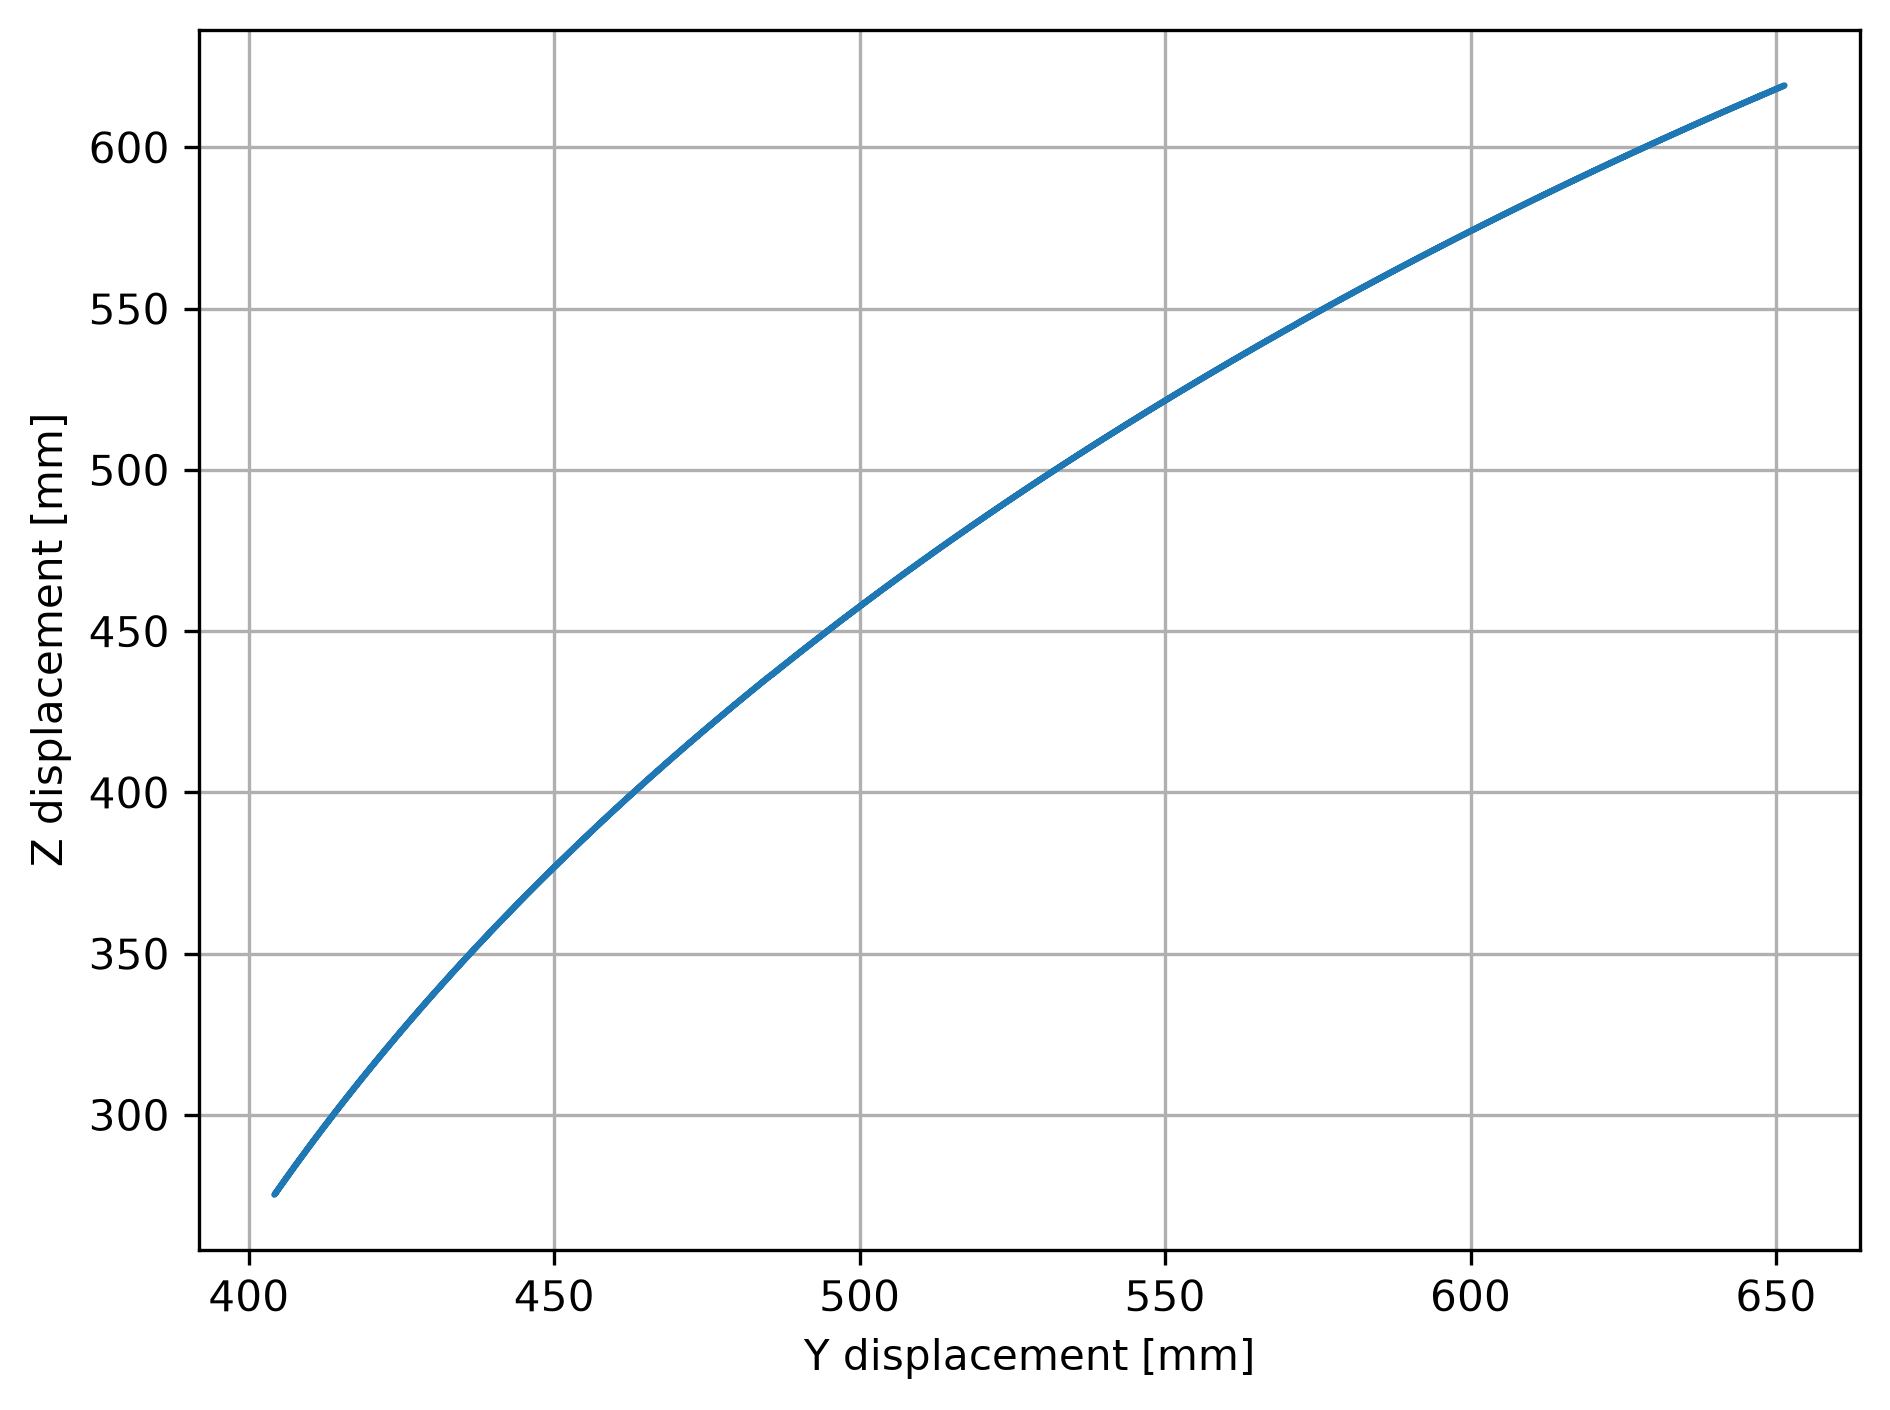

Done: Model 0


In [2]:
for file_path in excel_files_skel:
    file_name = os.path.splitext(os.path.basename(file_path))[0]

    sheet1 = read_sheet(file_path, "Sheet1")
    plot_sheet1(sheet1, file_name)

    print(f"Done: {file_name}")
    break
     

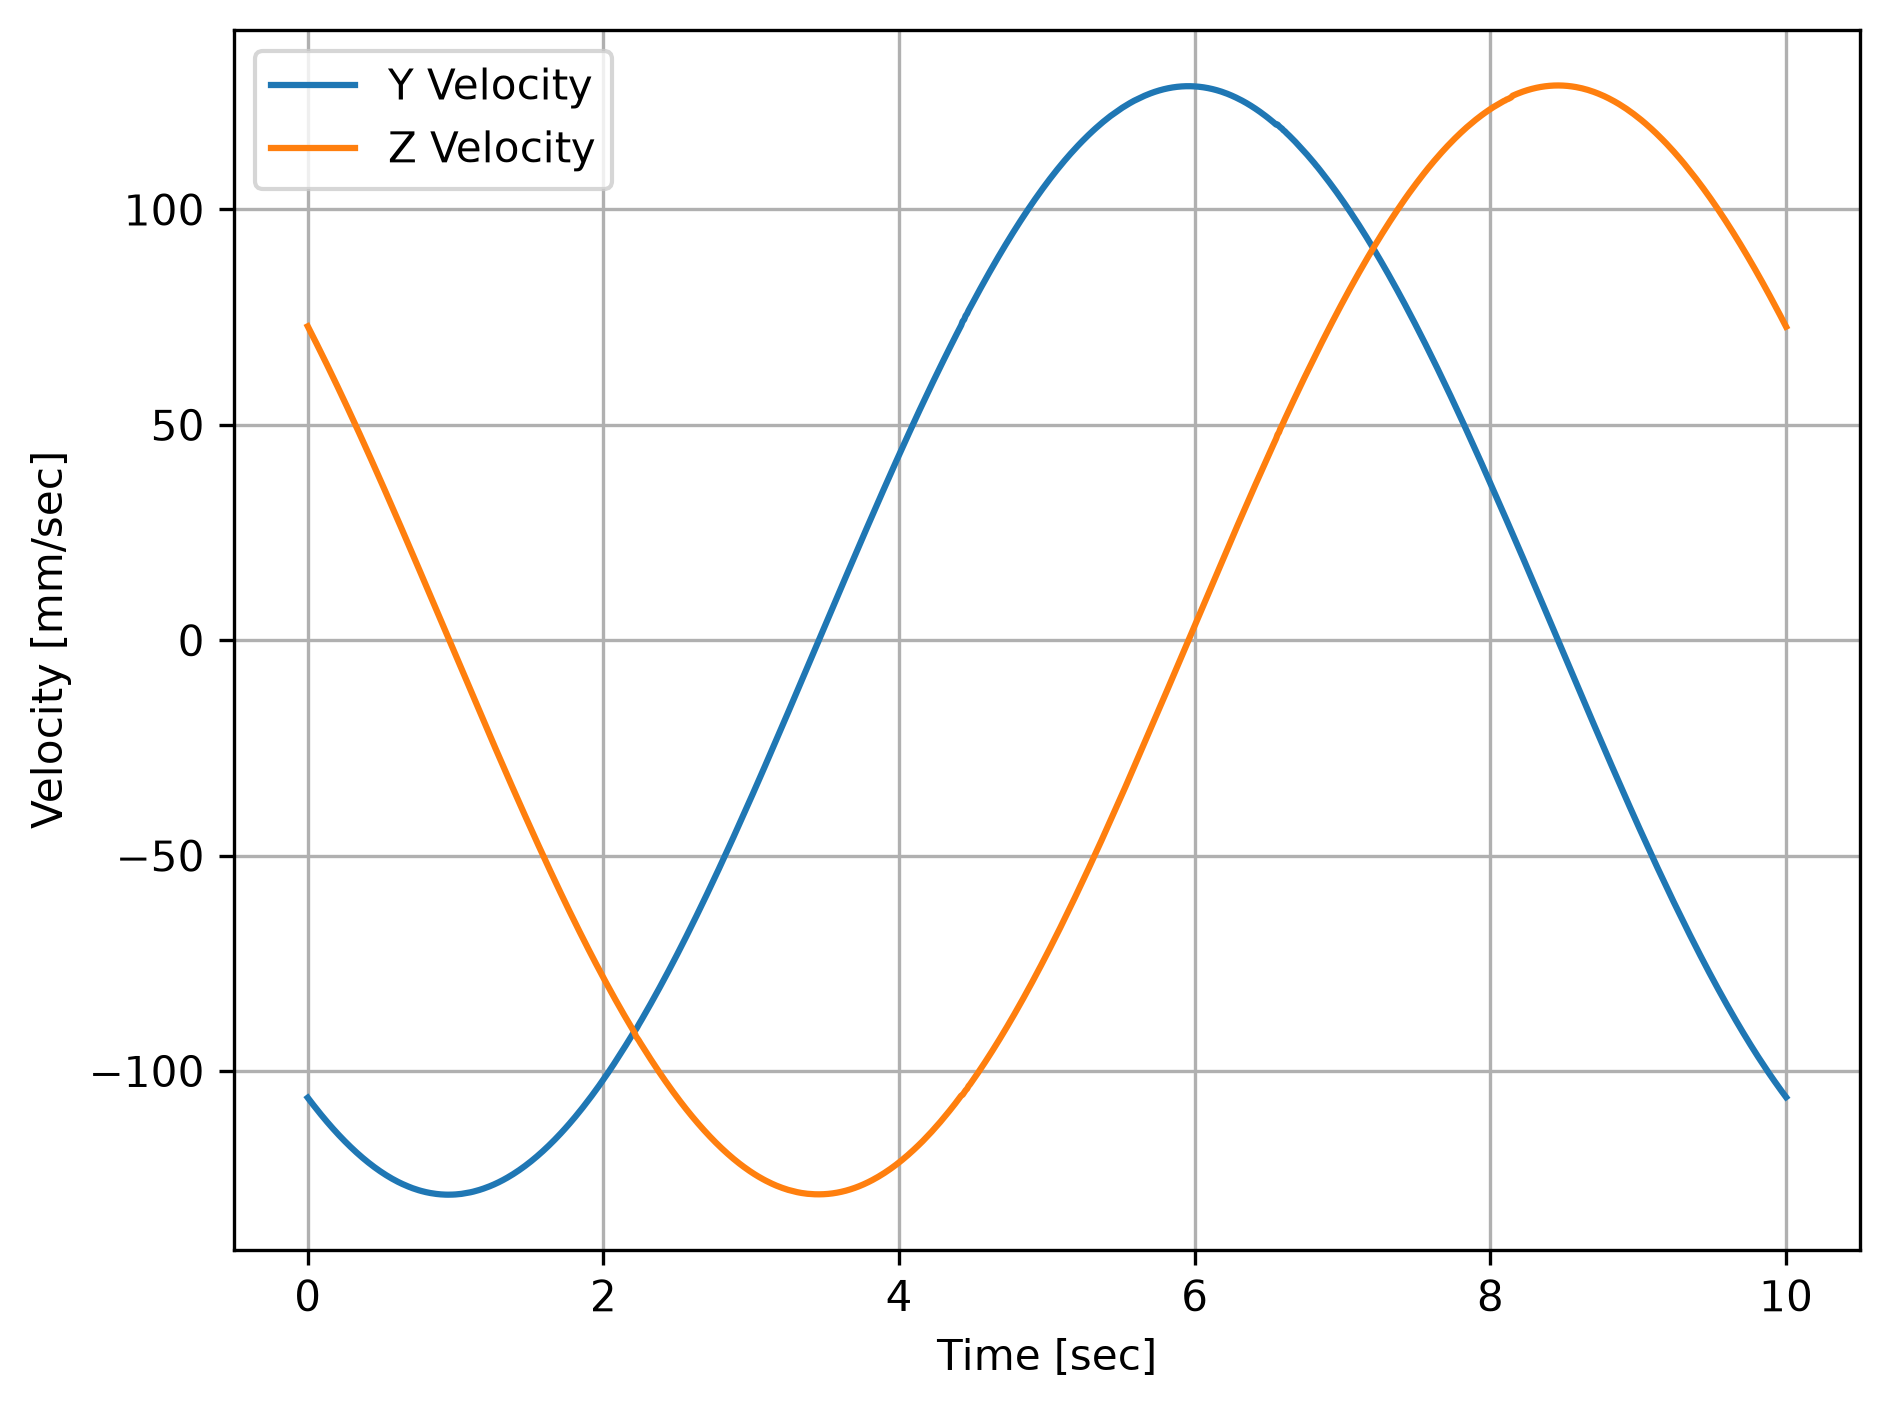

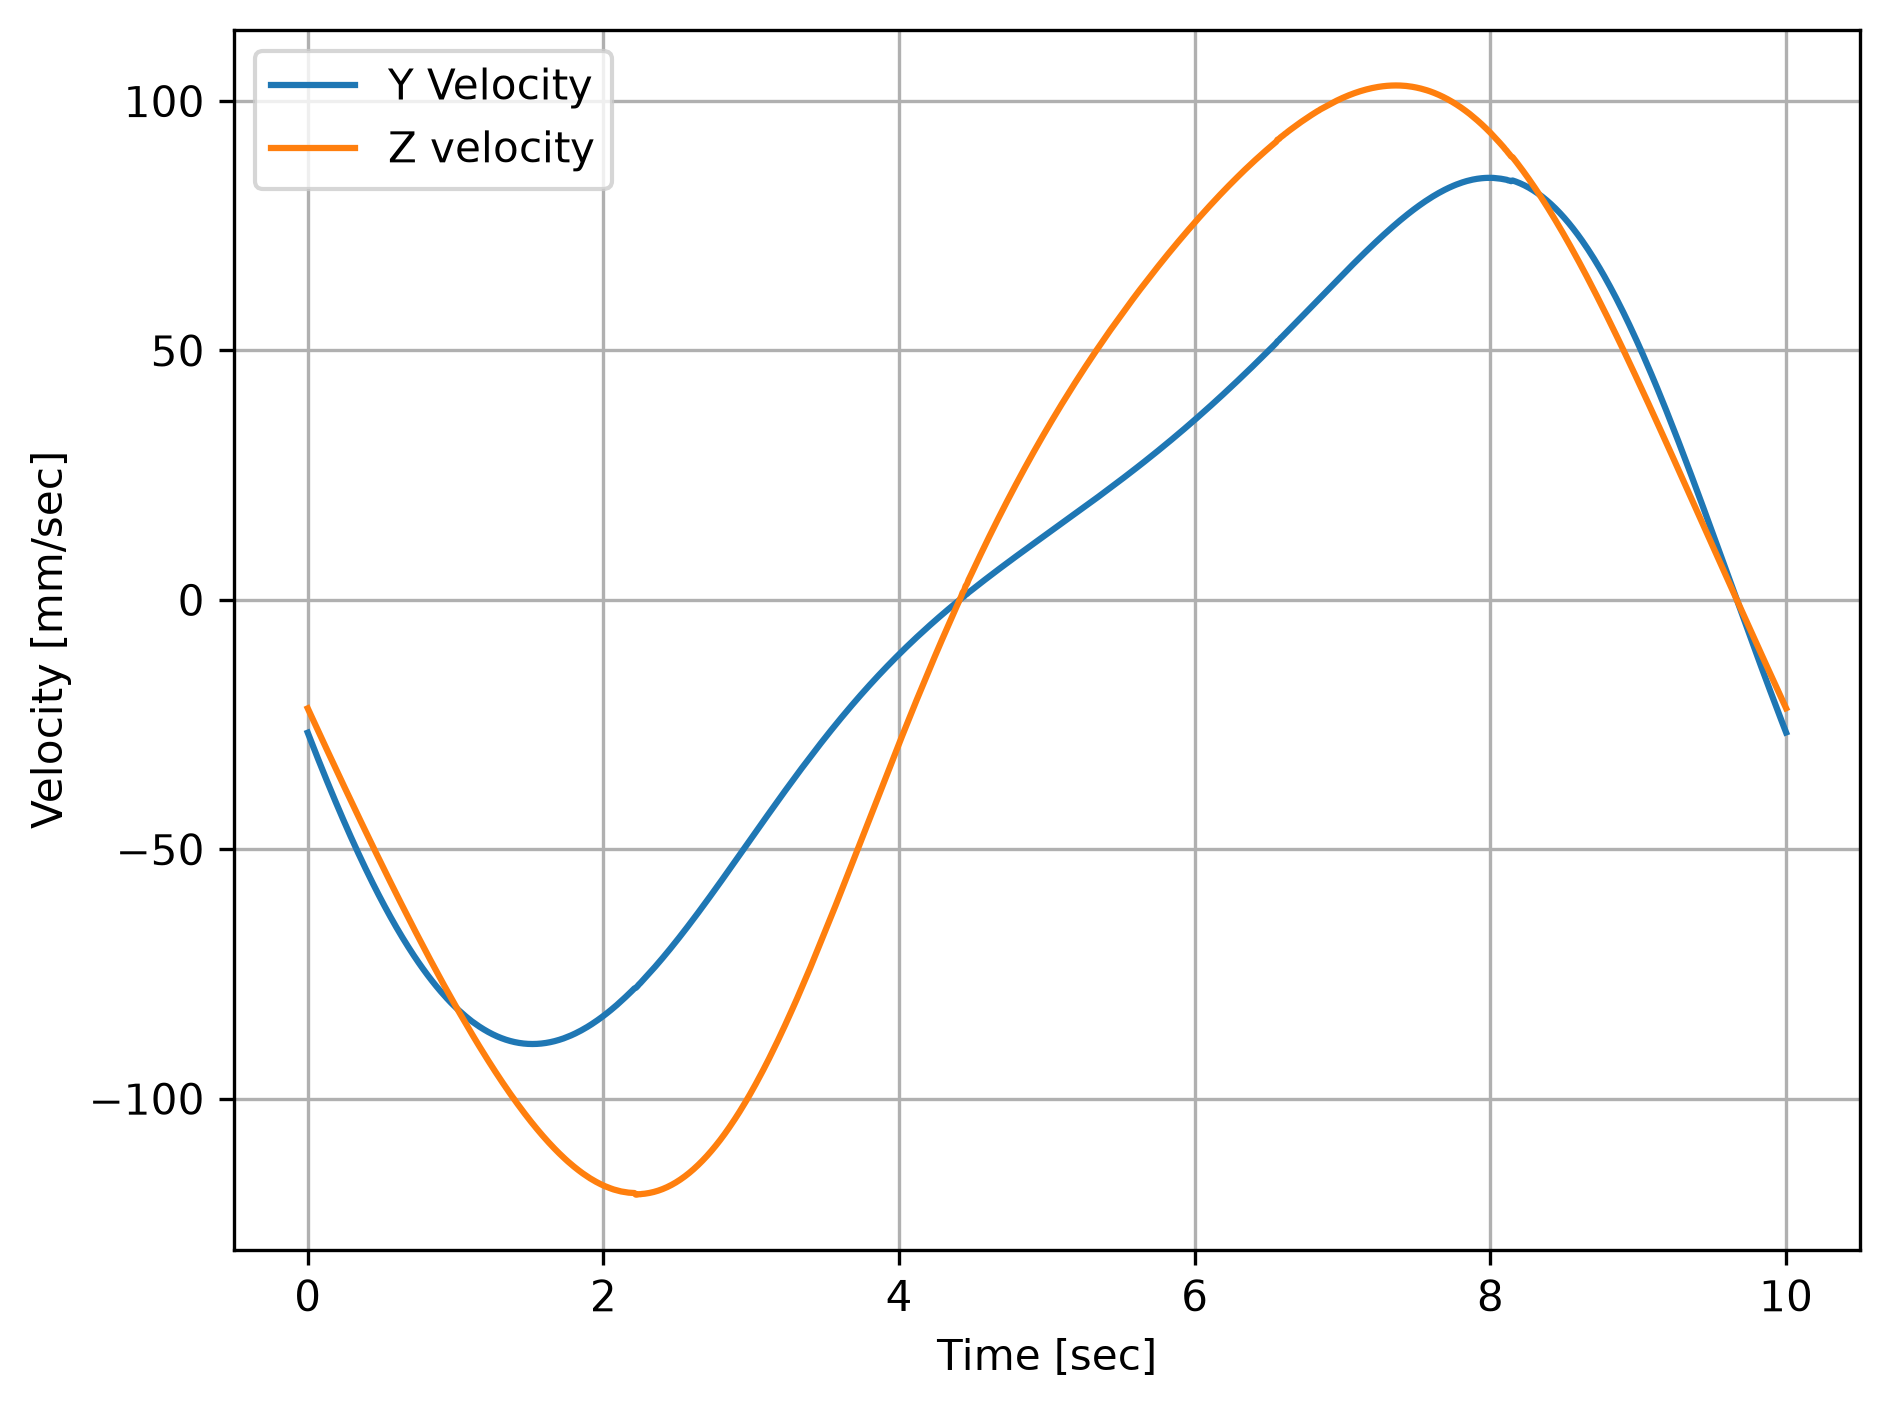

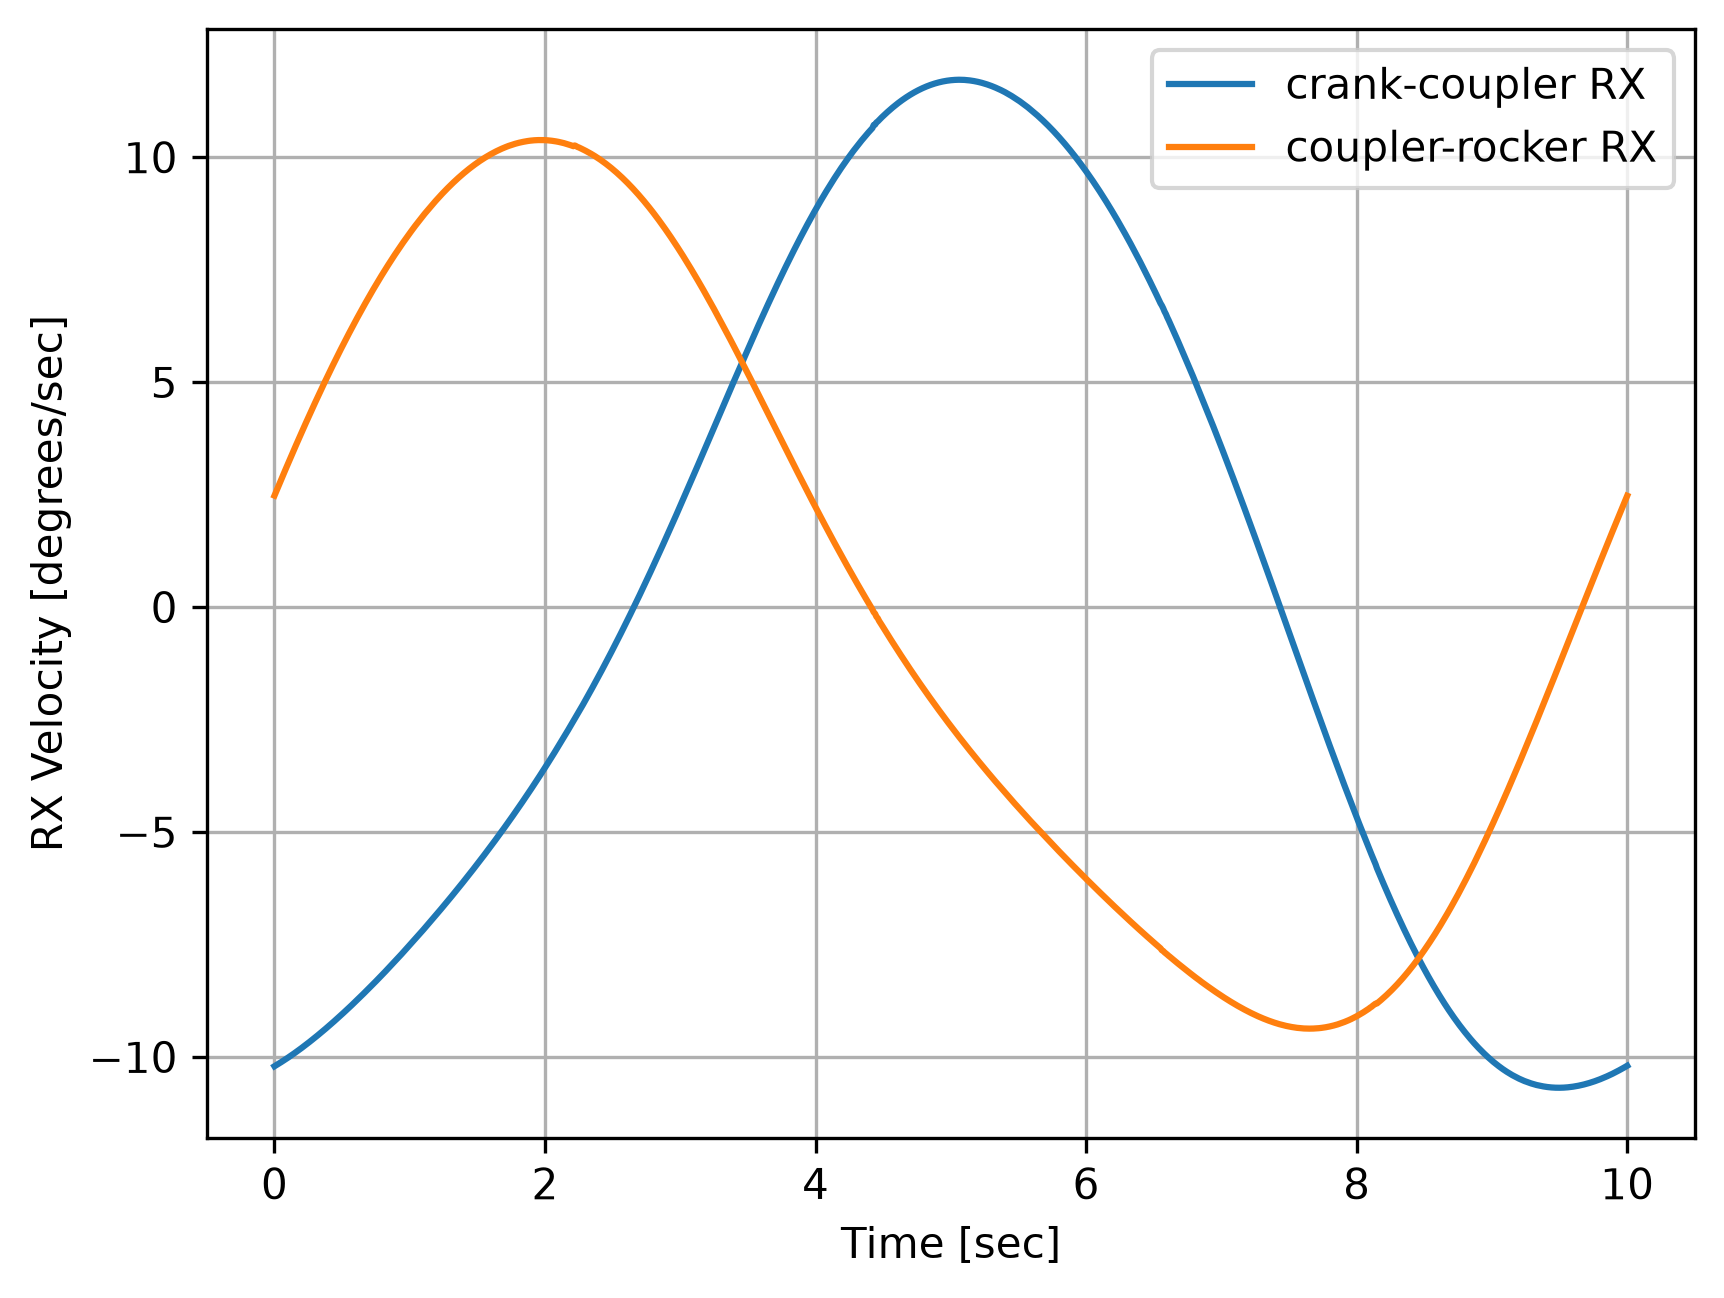

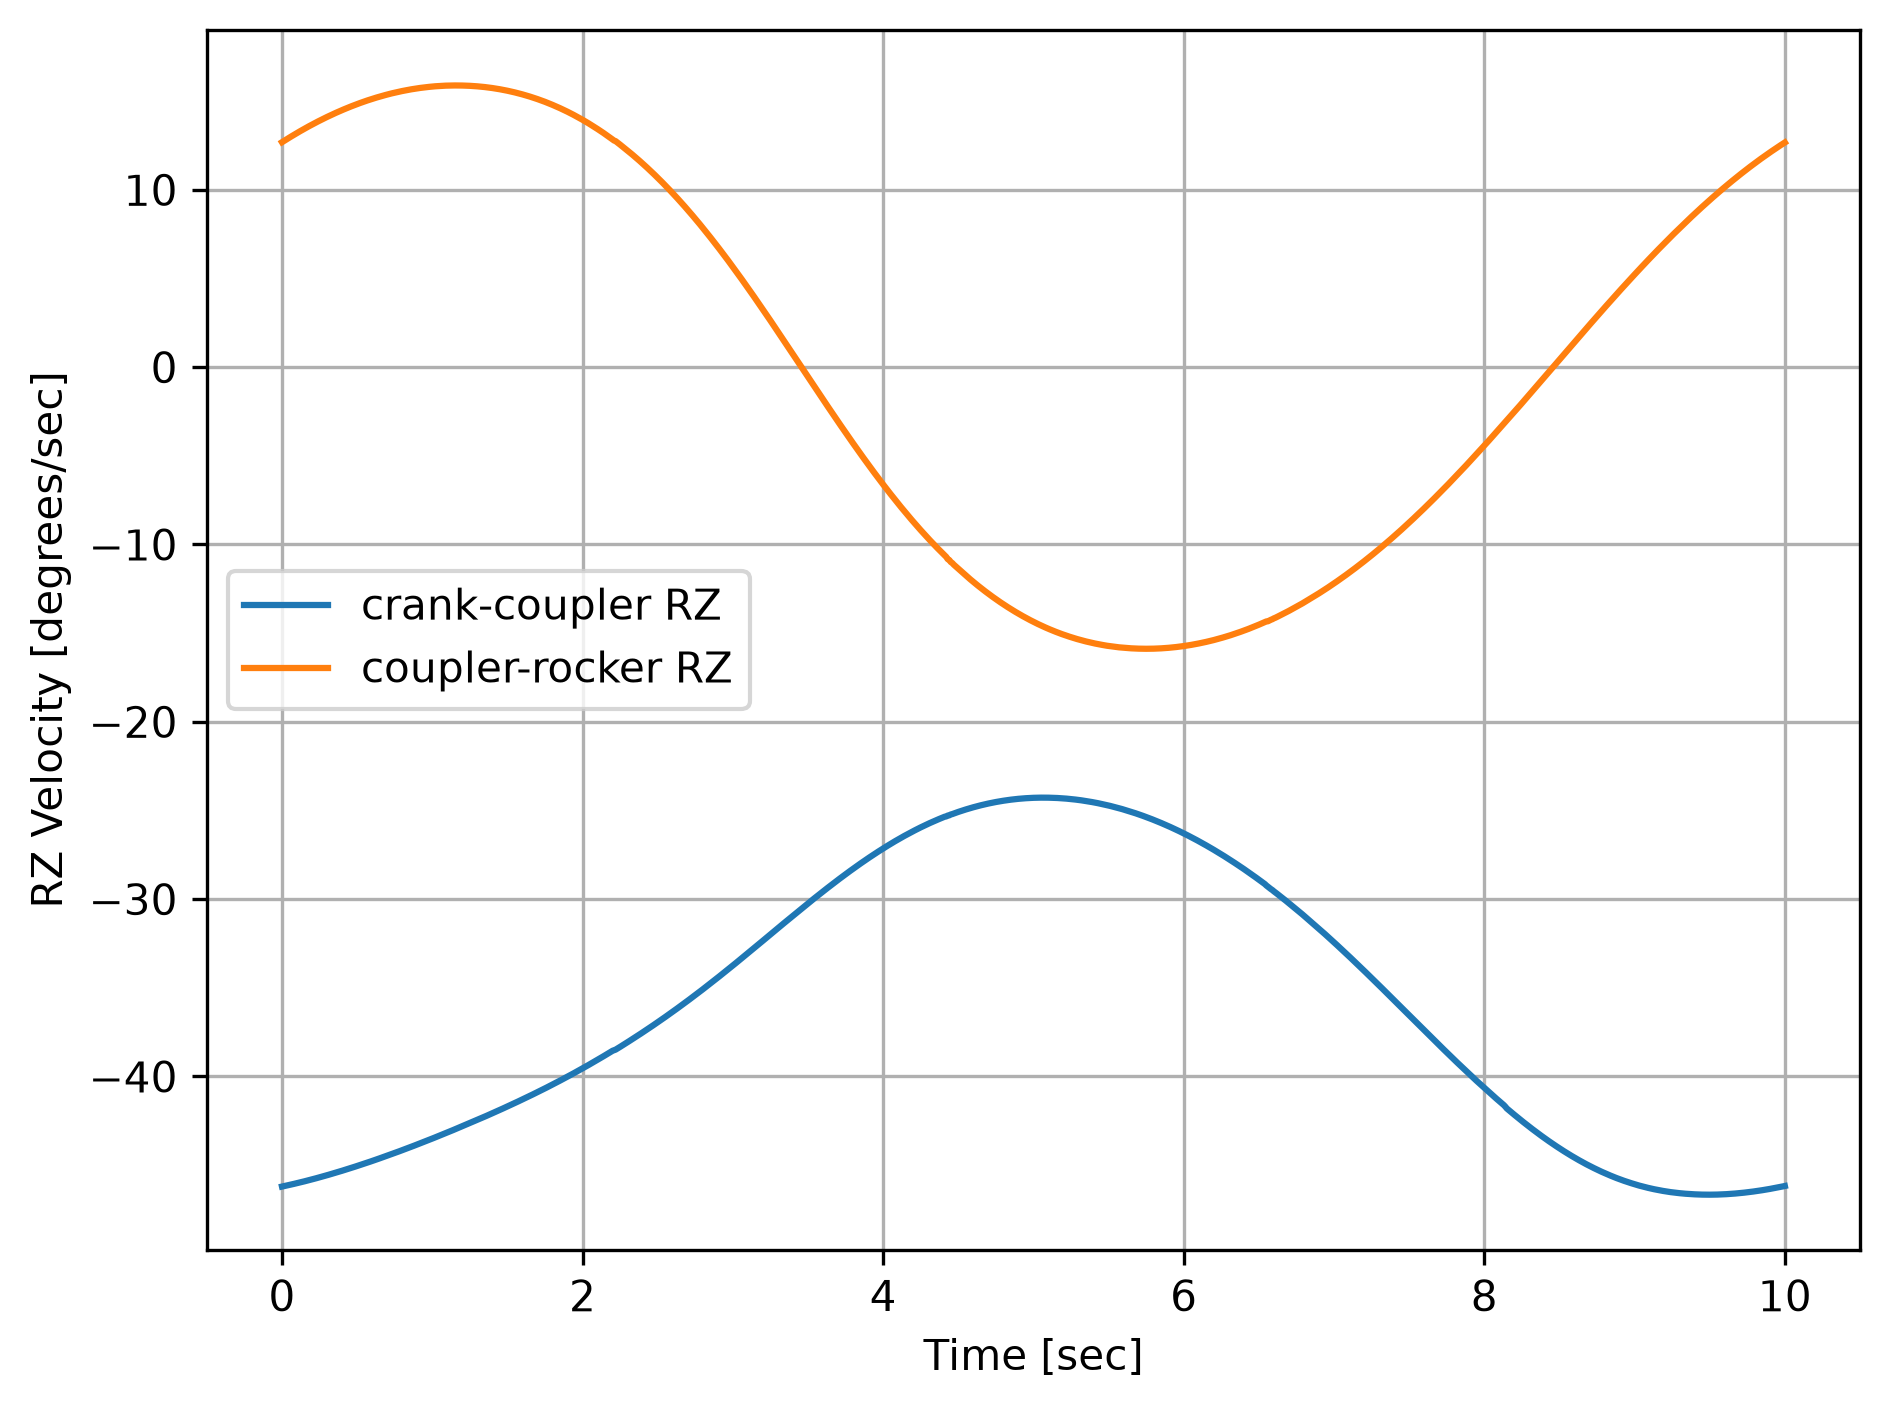

Done: Model 0


In [3]:
for file_path in excel_files_skel:
    file_name = os.path.splitext(os.path.basename(file_path))[0]

    sheet2 = read_sheet(file_path, "Sheet2")
    plot_sheet2(sheet2, file_name)

    print(f"Done: {file_name}")
    break

['Dynamic_Model\\Model 1.xlsx', 'Dynamic_Model\\Model 2.xlsx', 'Dynamic_Model\\Model 3.xlsx', 'Dynamic_Model\\Model 4.xlsx']
File: Model 1

Joint Forces (Sheet1)
         Joint  FY Min [N]  FY Max [N]  FZ Min [N]  FZ Max [N]
   crank-frame      29.373      83.127      86.310     114.204
 crank-coupler      29.466      83.031      62.959      90.662
coupler-rocker      29.753      82.602      -6.937      19.900
  rocker-frame     -82.446     -29.747      60.298      86.805

Power (Sheet2)  —  rotation speed: 36 deg/s  (0.6283 rad/s)
  Min torque : -22008.759 N·mm  (-22.008759 N·m)
  Max torque : 20610.823 N·mm  (20.610823 N·m)
  Min power  : -13.828511 W
  Max power  : 12.950162 W
  Mean power : -0.004020 W

All files processed.


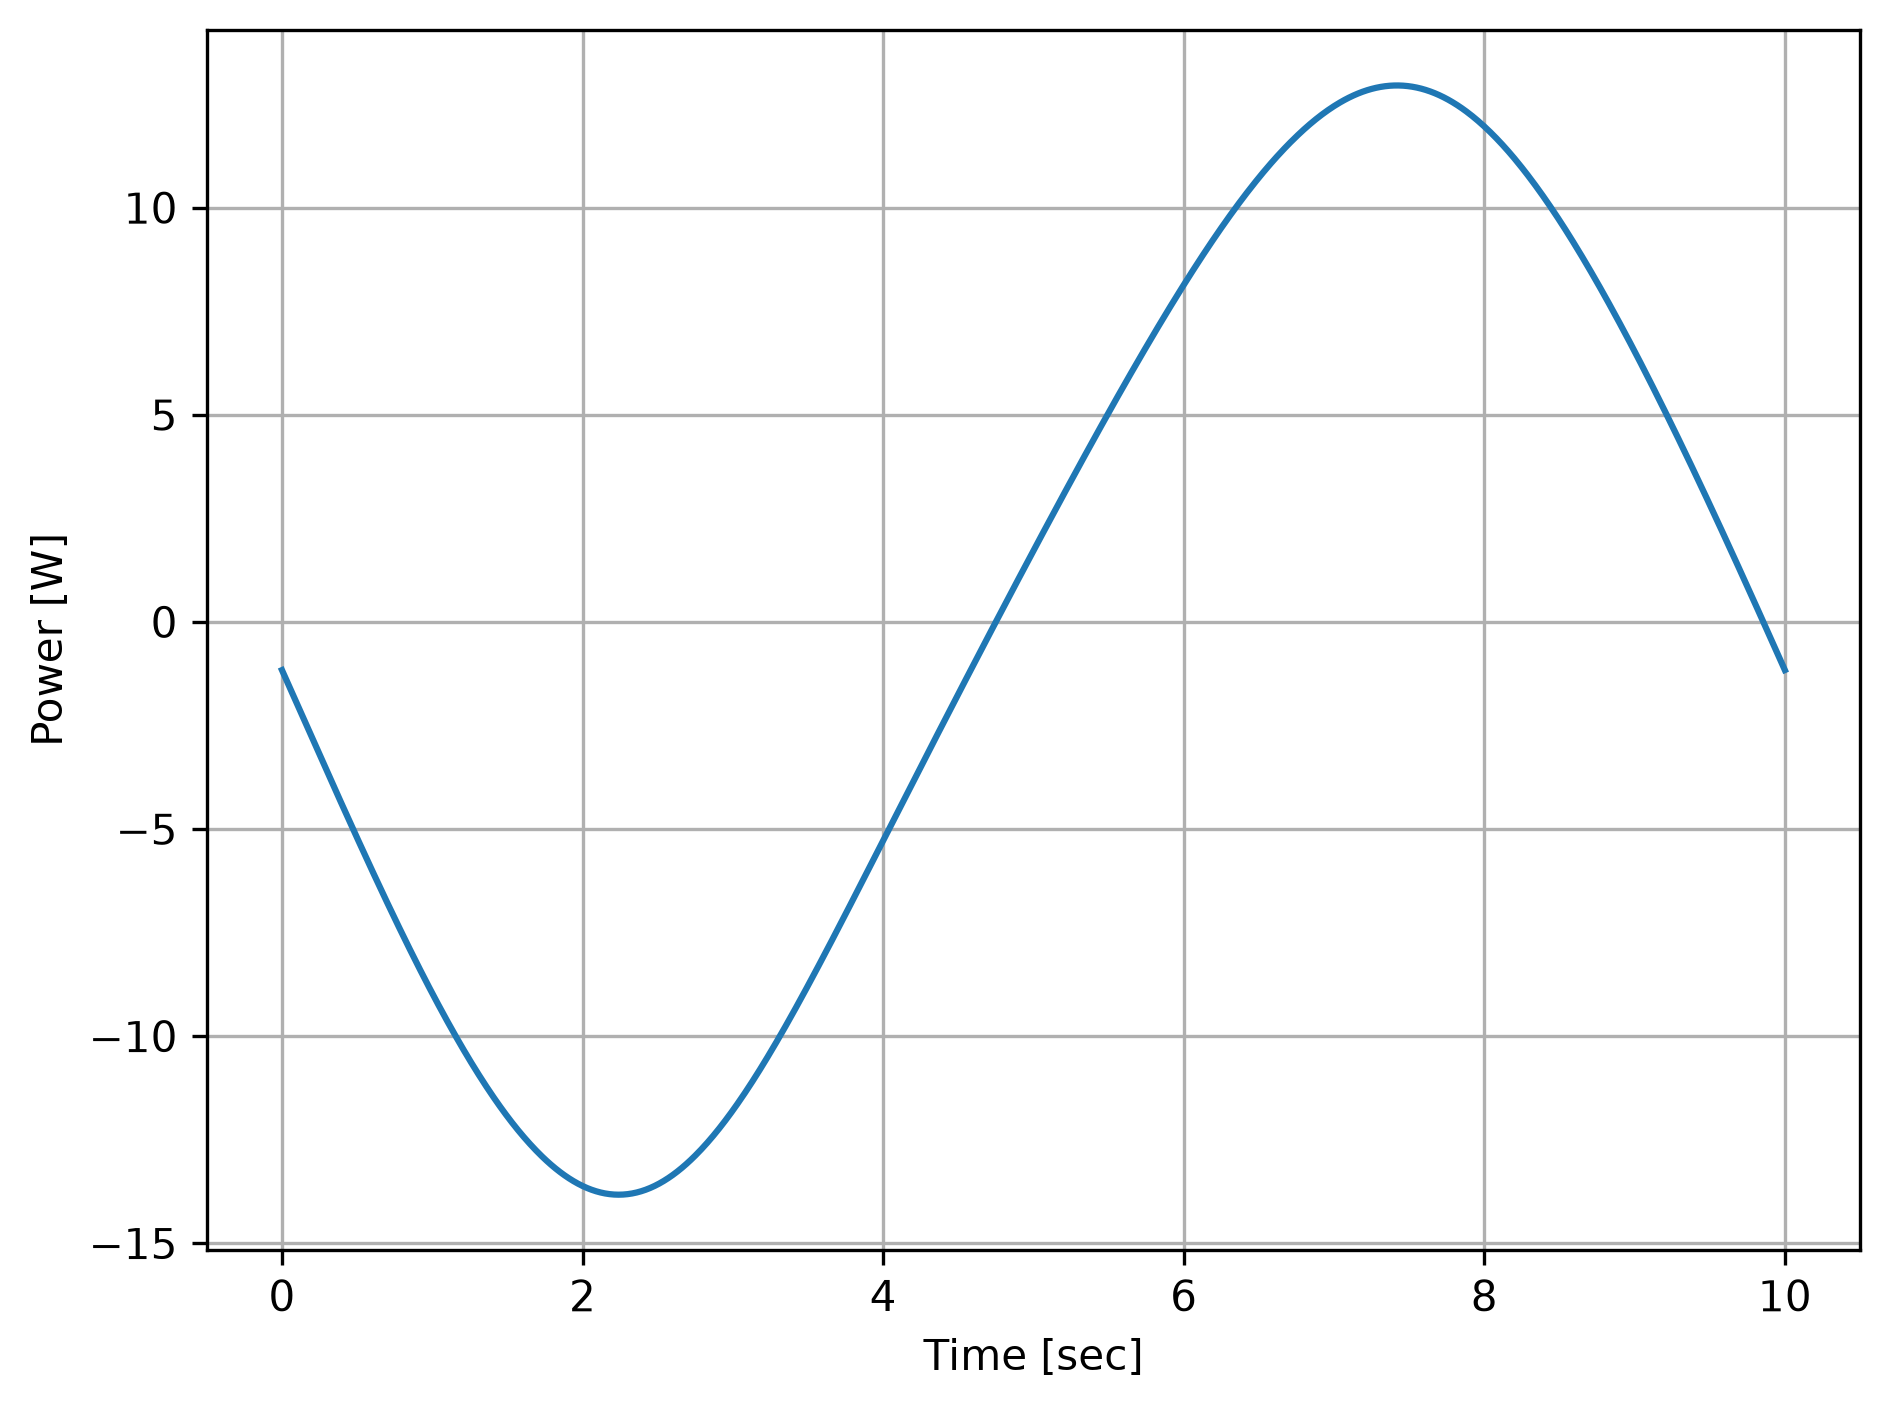

In [4]:
"""
Analyse dynamic model Excel files in the Dynamic_Model folder.

For each file:
  - Sheet1: print a table of min/max forces for every joint
  - Sheet2: compute and print power from torque * angular velocity
"""

import os
import glob
import pandas as pd

# ---------------------------------------------------------------------------
# SETTINGS
# ---------------------------------------------------------------------------

ROTATION_SPEED_DEG_PER_SEC = 36                          # degrees / sec
ROTATION_SPEED_RAD_PER_SEC = ROTATION_SPEED_DEG_PER_SEC * (3.141592653589793 / 180)  # radians / sec

excel_files = glob.glob(os.path.join("Dynamic_Model", "*.xlsx"))
print(excel_files)
for file_path in excel_files:

    file_name = os.path.splitext(os.path.basename(file_path))[0]
    print("=" * 60)
    print(f"File: {file_name}")
    print("=" * 60)

    sheet1 = pd.read_excel(file_path, sheet_name="Sheet1")
    sheet2 = pd.read_excel(file_path, sheet_name="Sheet2")

    # ===================================================================
    # SHEET 1 - MIN / MAX FORCES PER JOINT
    # ===================================================================

    crank_frame_FY_min   = sheet1["crank-frame->FY,Force(abs) [N]"].min()
    crank_frame_FY_max   = sheet1["crank-frame->FY,Force(abs) [N]"].max()
    crank_frame_FZ_min   = sheet1["crank-frame->FZ,Force(abs) [N]"].min()
    crank_frame_FZ_max   = sheet1["crank-frame->FZ,Force(abs) [N]"].max()

    crank_coupler_FY_min  = sheet1["crank-coupler->FY,Force(abs) [N]"].min()
    crank_coupler_FY_max  = sheet1["crank-coupler->FY,Force(abs) [N]"].max()
    crank_coupler_FZ_min  = sheet1["crank-coupler->FZ,Force(abs) [N]"].min()
    crank_coupler_FZ_max  = sheet1["crank-coupler->FZ,Force(abs) [N]"].max()

    coupler_rocker_FY_min = sheet1["coupler-rocker->FY,Force(abs) [N]"].min()
    coupler_rocker_FY_max = sheet1["coupler-rocker->FY,Force(abs) [N]"].max()
    coupler_rocker_FZ_min = sheet1["coupler-rocker->FZ,Force(abs) [N]"].min()
    coupler_rocker_FZ_max = sheet1["coupler-rocker->FZ,Force(abs) [N]"].max()

    rocker_frame_FY_min   = sheet1["rocker-frame->FY,Force(abs) [N]"].min()
    rocker_frame_FY_max   = sheet1["rocker-frame->FY,Force(abs) [N]"].max()
    rocker_frame_FZ_min   = sheet1["rocker-frame->FZ,Force(abs) [N]"].min()
    rocker_frame_FZ_max   = sheet1["rocker-frame->FZ,Force(abs) [N]"].max()

    force_table = pd.DataFrame({
        "Joint":       ["crank-frame",   "crank-coupler",   "coupler-rocker",   "rocker-frame"],
        "FY Min [N]":  [crank_frame_FY_min,  crank_coupler_FY_min,  coupler_rocker_FY_min,  rocker_frame_FY_min],
        "FY Max [N]":  [crank_frame_FY_max,  crank_coupler_FY_max,  coupler_rocker_FY_max,  rocker_frame_FY_max],
        "FZ Min [N]":  [crank_frame_FZ_min,  crank_coupler_FZ_min,  coupler_rocker_FZ_min,  rocker_frame_FZ_min],
        "FZ Max [N]":  [crank_frame_FZ_max,  crank_coupler_FZ_max,  coupler_rocker_FZ_max,  rocker_frame_FZ_max],
    })

    print("\nJoint Forces (Sheet1)")
    print(force_table.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

    # ===================================================================
    # SHEET 2 - POWER FROM TORQUE
    #
    # Power [W] = Torque [N·m] * angular velocity [rad/s]
    # Torque column is in N·mm so convert: divide by 1000
    # ===================================================================

    torque_Nmm = sheet2["Velocity36_RZ->TX,Torque(abs) [N-mm]"]
    torque_Nm  = torque_Nmm / 1000                                      # N·mm -> N·m

    power_W    = torque_Nm * ROTATION_SPEED_RAD_PER_SEC                 # W

    print(f"\nPower (Sheet2)  —  rotation speed: {ROTATION_SPEED_DEG_PER_SEC} deg/s"
          f"  ({ROTATION_SPEED_RAD_PER_SEC:.4f} rad/s)")
    print(f"  Min torque : {torque_Nmm.min():.3f} N·mm  ({torque_Nm.min():.6f} N·m)")
    print(f"  Max torque : {torque_Nmm.max():.3f} N·mm  ({torque_Nm.max():.6f} N·m)")
    print(f"  Min power  : {power_W.min():.6f} W")
    print(f"  Max power  : {power_W.max():.6f} W")
    print(f"  Mean power : {power_W.mean():.6f} W")
    print()
    time2 = sheet2.iloc[:, 2]
    plt.figure()
    plt.plot(time2, power_W)
    plt.xlabel("Time [sec]")
    plt.ylabel("Power [W]")
    plt.grid(True); plt.tight_layout()
    break

print("All files processed.")

